# <center> **PROJECT-3. EDA + Feature Engineering**

Импортируем необходимые библиотеки

In [343]:
import pandas as pd
import statistics
import re
import ast
from collections import Counter
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели 
from sklearn.model_selection import train_test_split 
import seaborn as sns
import category_encoders as ce # импорт для работы с кодировщиком
from sklearn.feature_selection import chi2 # хи-квадрат
from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

Загружаем и читаем данные

In [344]:
hotels = pd.read_csv('data\hotels.csv')
hotels.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


Первоначальная версия датасета содержит 17 полей со следующей информацией:
* hotel_address — адрес отеля;
* review_date — дата, когда рецензент разместил соответствующий отзыв;
* average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
* hotel_name — название отеля;
* reviewer_nationality — страна рецензента;
* negative_review — отрицательный отзыв, который рецензент дал отелю;
* review_total_negative_word_counts — общее количество слов в отрицательном отзыв;
* positive_review — положительный отзыв, который рецензент дал отелю;
* review_total_positive_word_counts — общее количество слов в положительном отзыве.
* reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;
* total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;
* total_number_of_reviews — общее количество действительных отзывов об отеле;
* tags — теги, которые рецензент дал отелю;
* days_since_review — количество дней между датой проверки и датой очистки;
* additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
* lat — географическая широта отеля;
* lng — географическая долгота отеля.

В каких столбцах данные содержат пропущенные значения:

In [345]:
cols_null_percent = hotels.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

lat    0.63288
lng    0.63288
dtype: float64

In [346]:
#создаем словарь имя столбца: число(признак) на который надо заменить пропуски
values = {
    'lat': hotels['lat'].mean(),
    'lng': hotels['lng'].mean(),
}
#заполняем пропуски в соответствии с заявленным словарем
hotels = hotels.fillna(values)
#выводим результирующую долю пропусков
hotels.isnull().mean()

hotel_address                                 0.0
additional_number_of_scoring                  0.0
review_date                                   0.0
average_score                                 0.0
hotel_name                                    0.0
reviewer_nationality                          0.0
negative_review                               0.0
review_total_negative_word_counts             0.0
total_number_of_reviews                       0.0
positive_review                               0.0
review_total_positive_word_counts             0.0
total_number_of_reviews_reviewer_has_given    0.0
reviewer_score                                0.0
tags                                          0.0
days_since_review                             0.0
lat                                           0.0
lng                                           0.0
dtype: float64

Проанализируем типы данных в признаках:

In [347]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

---

### <center> Подготовка к пробному запуску модели

#### Преобразование Датафрейма путем удаления признаков с типом OBJECT

In [348]:
hotels_drop = hotels.drop(['hotel_address','review_date','hotel_name','reviewer_nationality','negative_review',
                           'positive_review','tags','days_since_review'], axis = 1)
hotels_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 9 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                386803 non-null  int64  
 1   average_score                               386803 non-null  float64
 2   review_total_negative_word_counts           386803 non-null  int64  
 3   total_number_of_reviews                     386803 non-null  int64  
 4   review_total_positive_word_counts           386803 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  386803 non-null  int64  
 6   reviewer_score                              386803 non-null  float64
 7   lat                                         386803 non-null  float64
 8   lng                                         386803 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 26.6 MB


---

In [349]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
#X = hotels_drop.drop(['reviewer_score'], axis = 1)  
#y = hotels_drop['reviewer_score'] 

In [350]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [351]:
# Создаём модель  
#regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
#regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
#y_pred = regr.predict(X_test)  


In [352]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
#print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

Задача - улучшить метрику

---

Преобразуем время в формат datetime

In [353]:
hotels['review_date'] = pd.to_datetime(hotels['review_date'])

Из признака адрес вытащим страну

In [354]:
hotels['country'] = hotels['hotel_address'].apply(lambda x: ' '.join(x.split(' ')[-2:]) if x.split(' ')[-1] == 'Kingdom' else x.split(' ')[-1])

In [355]:
hotels['country'].value_counts()

country
United Kingdom    196774
Spain              45132
France             44830
Netherlands        43006
Austria            29178
Italy              27883
Name: count, dtype: int64

---

In [356]:
hotels['hotel_name'].nunique()

1492

Всего 1492 уникальных названия отелей.

Если кодировать бинарным способом появится 11 новых признаков

---

In [357]:
hotels['review_date'].max()

Timestamp('2017-08-03 00:00:00')

In [358]:
hotels['review_date'].min()

Timestamp('2015-08-04 00:00:00')

Создадим признак - разница в днях между самым первым отзывом и последующими

In [359]:
diff_day = hotels['review_date'].min()
hotels['days_diff'] = (hotels['review_date'] - diff_day).dt.days

---

Посчитаем количество уникальных тегов в датасете

In [360]:
tag_list = []
for i in range(hotels.shape[0]):
    input_string = hotels['tags'].iloc[i]
    data_list = [item.strip() for item in ast.literal_eval(input_string)]
    for tag in data_list:
        if tag not in tag_list:
            tag_list.append(tag)
print(len(tag_list))

2368


Функция преобразования строки в список

In [361]:
def tags_to_list(string):
    input_string = string
    return([item.strip() for item in ast.literal_eval(input_string)])

Применим функцию преобразования и сделаем признак Теги удобным для использования


In [362]:
hotels['tags']=hotels['tags'].apply(tags_to_list)

Посчитаем общее количество опубликованных тегов и запишем их в teg_list

In [363]:
tag_list = []
for i in range(hotels.shape[0]):
    for tag in hotels['tags'].iloc[i]:
        tag_list.append(tag)
len(tag_list)

1767522

С помощью счетчика найдем самый часто публикуемый тег, а также то, что тег 'Stayed 1 night' употреблялся чаще, чем 'Stayed 2 nights'

In [364]:
counter_tags = Counter(tag_list)
print(counter_tags.most_common(100))


[('Leisure trip', 313593), ('Submitted from a mobile device', 230778), ('Couple', 189212), ('Stayed 1 night', 145373), ('Stayed 2 nights', 100263), ('Solo traveler', 81235), ('Stayed 3 nights', 72000), ('Business trip', 61989), ('Group', 49088), ('Family with young children', 45836), ('Stayed 4 nights', 35748), ('Double Room', 26386), ('Standard Double Room', 24151), ('Superior Double Room', 23550), ('Family with older children', 19802), ('Deluxe Double Room', 18623), ('Double or Twin Room', 16824), ('Stayed 5 nights', 15611), ('Standard Double or Twin Room', 13062), ('Classic Double Room', 12716), ('Superior Double or Twin Room', 10238), ('2 rooms', 9287), ('Stayed 6 nights', 7399), ('Standard Twin Room', 7325), ('Single Room', 7227), ('Twin Room', 6279), ('Stayed 7 nights', 5549), ('Executive Double Room', 4763), ('Classic Double or Twin Room', 4576), ('Superior Twin Room', 4540), ('Club Double Room', 4485), ('Deluxe Double or Twin Room', 4465), ('Queen Room', 4071), ('Deluxe King Ro

Количество тегов для каждого путешественника отличается. Ниже пример для количества тегов меньше 4 - 4.196. Потом будем бороться с пропусками
>Вывод: нельзя использовать лямбда-функцию с индексацией в списке тегов

In [365]:
# Получим список индексов, где количество тегов меньше 4
count = []
for i in range(hotels.shape[0]):
    if len(hotels['tags'].iloc[i]) < 4:
        count.append(i)
print(count)
print(len(count))

[71, 74, 85, 94, 148, 588, 597, 658, 766, 767, 821, 1102, 1235, 1267, 1346, 1363, 1365, 1453, 1543, 1584, 1657, 1674, 1865, 2171, 2177, 2312, 2320, 2407, 2456, 2480, 2484, 2566, 2723, 2775, 2853, 3259, 3310, 3377, 3589, 3611, 3659, 3800, 4050, 4127, 4173, 4185, 4202, 4264, 4366, 4385, 4402, 4452, 4533, 4763, 4818, 5003, 5065, 5220, 5273, 5492, 5495, 5535, 5577, 5668, 5754, 5823, 5881, 5954, 5962, 5980, 5993, 6125, 6191, 6291, 6445, 6455, 7167, 7207, 7328, 7462, 7492, 7496, 7521, 7731, 7760, 7905, 7971, 8122, 8517, 8630, 8665, 8764, 9074, 9080, 9136, 9375, 9467, 9502, 9604, 9673, 9757, 9764, 9961, 9963, 10014, 10016, 10145, 10289, 10433, 10437, 10438, 10606, 10733, 10838, 10945, 10958, 11079, 11180, 11201, 11238, 11403, 11442, 11458, 11635, 11654, 11748, 11750, 11795, 11835, 12374, 12499, 12560, 12646, 12787, 12820, 12895, 12904, 12938, 12939, 12969, 12992, 13050, 13139, 13157, 13239, 13552, 13615, 13799, 13817, 13920, 13951, 14013, 14086, 14409, 14410, 14559, 14632, 14670, 14766, 14791

Функция для поиска в тегах количества ночей пребывания в отеле

In [366]:
def staying_in(lst):
    regex = r'\d+'
    for tag in lst:
        if 'Stayed' in tag:
            match = re.search(regex, tag)
            if match:
                return int(match.group())
    return None

Создаем новый признак количества ночей пребывания в отеле

In [367]:
hotels['staying_in'] = hotels['tags'].apply(staying_in)

Новый признак - тип поездки

In [368]:
def type_of_trip(lst):
    for tag in lst:
        if 'Business' in tag:
            return 'Business trip'
        elif 'Leisure' in tag:
            return 'Leisure trip'

In [369]:
hotels['type_of_trip'] = hotels['tags'].apply(type_of_trip)

In [370]:
hotels['tags'].iloc[17]

['Leisure trip',
 'Group',
 'Standard Room',
 'Stayed 2 nights',
 'Submitted from a mobile device']

Признак Количество гостей

In [371]:
def guests(lst):
    for tag in lst:
        if 'Couple' in tag:
            return 'Couple'
        elif 'Solo ' in tag:
            return 'Solo traveler'
        elif 'young' in tag:
            return 'Family with young children'
        elif 'Group' in tag:
            return 'Group'
        elif 'older' in tag:
            return 'Family with older children'
        elif 'Travelers' in tag:
            return 'Travelers with friends'
        elif 'With a pet' in tag:
            return 'With a pet'

In [372]:
hotels['guests'] = hotels['tags'].apply(guests)

Создаем признак тип комнаты:

In [373]:
def roome_type(lst):
    for tag in lst:
        if 'Room' in tag:
            return tag
        elif 'rooms ' in tag:
            return tag
        elif 'Suite' in tag:
            return tag
        elif 'Double' in tag:
            return tag
        elif 'Guestroom' in tag:
            return tag
        elif 'Standard' in tag:
            return tag
        elif 'Studio' in tag:
            return tag

In [374]:
hotels['roome_type'] = hotels['tags'].apply(roome_type)

Создаем признак Отправки отзыва с мобильного телефона

In [375]:
def mobile_device(lst):
    return 1 if 'Submitted from a mobile device' in lst else 0

In [376]:
hotels['mobile_device'] = hotels['tags'].apply(mobile_device)

---

Выделим из признака 'days_since_review' число 

In [377]:
regex = '\d*' # регулярное выражение для нахождения чисел
hotels['days_since_review'] = hotels['days_since_review'].str.findall(regex).str.get(0)

---

Проанализируем 100 самых часто встречающихся отрицательных отзывов

In [378]:
hotels['negative_review'].value_counts().nlargest(100).index

Index(['No Negative', ' Nothing', ' Nothing ', ' nothing', ' N A', ' None',
       ' ', ' N a', ' Breakfast', ' Small room', ' Location', ' All good',
       ' Everything', ' Nothing really', ' none', ' nothing ',
       ' No complaints', ' Nil', ' Nothing really ', ' Price', ' n a',
       ' Nothing to dislike', ' Nothing at all', ' Nothing at all ',
       ' Small rooms', ' None ', ' No complaints ', ' All good ', ' NA',
       ' Expensive', ' Absolutely nothing ', ' Can t think of anything ',
       ' Room size', ' Very small room', ' Everything was perfect',
       ' Nothing to dislike ', ' Staff', ' Everything was great ', ' No',
       ' Everything was perfect ', ' Nothing to complain about ', ' Leaving ',
       ' NOTHING', ' Leaving', ' Na', ' Nothing not to like', ' See above',
       ' Everything was great', ' small room', ' Can t think of anything',
       ' Liked everything', ' breakfast', ' Not much', ' location',
       ' Having to leave ', ' Non', ' Parking', ' Expensive

Проведя визуальный анализ, замечаешь, что в отрицательном отзыве мало кто пишет отрицательного. Наоборот, пишут в эту графу, что не о чем написать.

Если человеку не понравилось что-то конкретное, он перечисляет это, не используя слова "Nothing", "No", "NA"

Преобразуем этот признак следующим образом - 0, если нет жалоб, 1 - если есть жалобы

In [379]:
list_of_NOT_negatives = ['No Negative', ' Nothing', ' Nothing ', ' nothing', ' N A', ' None',
       ' ', ' N a',' All good',
       ' Nothing really', ' none', ' nothing ',
       ' No complaints', ' Nil', ' Nothing really ',' n a',
       ' Nothing to dislike', ' Nothing at all', ' Nothing at all ',
       ' None ', ' No complaints ', ' All good ', ' NA',' Absolutely nothing ', ' Can t think of anything ',
       ' Everything was perfect', ' There was nothing I didn t like ',
       ' Nothing to dislike ',' Everything was great ', ' No',
       ' Everything was perfect ', ' Nothing to complain about ',
       ' NOTHING',' Na', ' Nothing not to like',
       ' Everything was great', ' Can t think of anything']
def negative(string):
    if string in list_of_NOT_negatives:
        return 0
    else:
        return 1

In [380]:
hotels['is_it_negative'] = hotels['negative_review'].apply(negative)

Создадим признак - коэффициент негатива. Умножим прзнак is_it_negative на количество негативных слов. Если значение is_it_negative == 0 - т.е. он не негативный, то итоговый коэффициент будет равен 0.
Если is_it_negative == 1, то его умножение на количество слов будет отражать степень возмущения человека.
Логика подсказывает, что когда человек чем-то не доволен, ему есть что рассказать

In [381]:
hotels['negative_coefficient'] = hotels['is_it_negative'] * hotels['review_total_negative_word_counts']

---

Проанализируем самые часто встречающиеся положительные отзывы

In [382]:
hotels['positive_review'].value_counts().nlargest(80).index

Index(['No Positive', ' Location', ' Everything', ' location', ' Nothing',
       ' The location', ' Great location', ' Good location', ' Location ',
       ' Breakfast', ' Everything ', ' Friendly staff', ' Staff',
       ' Excellent location', ' Great location ', ' Location and staff',
       ' everything', ' Good location ', ' Nothing ', ' nothing', ' Comfy bed',
       ' The location ', ' good location', ' The staff', ' the location',
       ' Location was good', ' Location was great', ' Location staff',
       ' Good breakfast', ' ', ' All', ' Perfect location', ' Every thing',
       ' Clean', ' Excellent location ', ' Everything was perfect',
       ' Location is great', ' great location', ' Very friendly staff',
       ' Location is good', ' Comfortable bed', ' Cleanliness',
       ' Location location location', ' Breakfast was good',
       ' Everything was perfect ', ' Great breakfast', ' Central location',
       ' Location was excellent', ' Position', ' breakfast', ' Helpfu

Создадим список самых часто встречающихся неПозитивных слов в позитивных отзывах. Функция для создания признака позитивный отзыв или нет

In [383]:
list_of_NOT_pozitives = ['No Positive',' Nothing',
        ' Nothing ', ' nothing']
def pozitive(string):
    if string in list_of_NOT_pozitives:
        return 0
    else:
        return 1

Создаем признак Позитивный ли отзыв?

In [384]:
hotels['is_it_pozitive'] = hotels['positive_review'].apply(pozitive)

Создаем признак - коэффициент, который усиливает степеь позитивного отзыва и обнуляет, если в позитивном отзыве были сказаны негативные слова

In [385]:
hotels['pozitive_coefficient'] = hotels['is_it_pozitive'] * hotels['review_total_positive_word_counts']

---

Обработка пропусков

In [386]:
hotels.shape

(386803, 28)

In [387]:
# В каких столбцах есть пропущенные значения:
cols_null_percent = hotels.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

roome_type      3.542113
type_of_trip    2.896306
staying_in      0.037745
dtype: float64

In [388]:

#создаем словарь имя столбца: число(признак) на который надо заменить пропуски
values = {
    'lat': hotels['lat'].mean(),
    'lng': hotels['lng'].mean(),
    'roome_type': hotels['roome_type'].mode().iloc[0],
    'type_of_trip': hotels['type_of_trip'].mode().iloc[0],
    'staying_in': hotels['staying_in'].median()
}
#заполняем пропуски в соответствии с заявленным словарем
hotels = hotels.fillna(values)
#выводим результирующую долю пропусков
hotels.isnull().mean()

hotel_address                                 0.0
additional_number_of_scoring                  0.0
review_date                                   0.0
average_score                                 0.0
hotel_name                                    0.0
reviewer_nationality                          0.0
negative_review                               0.0
review_total_negative_word_counts             0.0
total_number_of_reviews                       0.0
positive_review                               0.0
review_total_positive_word_counts             0.0
total_number_of_reviews_reviewer_has_given    0.0
reviewer_score                                0.0
tags                                          0.0
days_since_review                             0.0
lat                                           0.0
lng                                           0.0
country                                       0.0
days_diff                                     0.0
staying_in                                    0.0


---

Кодирование категориальных признаков

In [389]:
# Кодировка признака Страна расположения отеля. 6 уникальных категорий

encoder = ce.OneHotEncoder(cols=['country'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(hotels['country'])
hotels = pd.concat([hotels, type_bin], axis=1)

In [390]:
# Удаляем первоначальный признак hotel_address и country
hotels = hotels.drop(['hotel_address','country'],axis = 1)

In [391]:
# Кодировка признака 'hotel_name'. 1492 уникальных категорий
bin_encoder = ce.BinaryEncoder(cols=['hotel_name']) # указываем столбец для кодирования

type_bin = bin_encoder.fit_transform(hotels['hotel_name'])
hotels = pd.concat([hotels, type_bin], axis=1)

In [392]:
# Удаляем первоначальный признак 'hotel_name'
hotels = hotels.drop('hotel_name',axis = 1)

In [393]:
# Кодировка признака 'reviewer_nationality'. 225 уникальных категорий
bin_encoder = ce.BinaryEncoder(cols=['reviewer_nationality']) # указываем столбец для кодирования

type_bin = bin_encoder.fit_transform(hotels['reviewer_nationality'])
hotels = pd.concat([hotels, type_bin], axis=1)

In [394]:
# Удаляем первоначальный признак 'hotel_name'
hotels = hotels.drop('reviewer_nationality',axis = 1)

In [395]:
# Удаляем категориальные признаки 'negative_review', 'positive_review', 'tags' так как они уже были преобразованы и данные из них были исползованы для создания других признаков
hotels = hotels.drop(['negative_review','positive_review','tags','is_it_negative', 'is_it_pozitive'],axis = 1)

In [396]:
# Кодировка признака 'type_of_trip'. 2 уникальных категории

encoder = ce.OneHotEncoder(cols=['type_of_trip'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(hotels['type_of_trip'])
hotels = pd.concat([hotels, type_bin], axis=1)

In [397]:
# Удаляем первоначальный признак 'type_of_trip'
hotels = hotels.drop('type_of_trip',axis = 1)

In [398]:
# Кодировка признака 'guests'. 7 уникальных категории

encoder = ce.OneHotEncoder(cols=['guests'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(hotels['guests'])
hotels = pd.concat([hotels, type_bin], axis=1)

In [399]:
# Удаляем первоначальный признак 'type_of_trip'
hotels = hotels.drop('guests',axis = 1)

In [400]:
# Кодировка признака 'roome_type'. >300 уникальных категорий
bin_encoder = ce.BinaryEncoder(cols=['roome_type']) # указываем столбец для кодирования

type_bin = bin_encoder.fit_transform(hotels['roome_type'])
hotels = pd.concat([hotels, type_bin], axis=1)

In [401]:
# Удаляем первоначальный признак 'roome_type'
hotels = hotels.drop('roome_type',axis = 1)

In [402]:
# Удаляем первоначальный признак 'review_date'
hotels = hotels.drop('review_date',axis = 1)

In [403]:
# Преобразуем признак 'staying_in' в int
hotels['staying_in'] = hotels['staying_in'].astype(int)

---

In [404]:
hotels.columns

Index(['additional_number_of_scoring', 'average_score',
       'review_total_negative_word_counts', 'total_number_of_reviews',
       'review_total_positive_word_counts',
       'total_number_of_reviews_reviewer_has_given', 'reviewer_score',
       'days_since_review', 'lat', 'lng', 'days_diff', 'staying_in',
       'mobile_device', 'negative_coefficient', 'pozitive_coefficient',
       'country_United Kingdom', 'country_France', 'country_Netherlands',
       'country_Italy', 'country_Austria', 'country_Spain', 'hotel_name_0',
       'hotel_name_1', 'hotel_name_2', 'hotel_name_3', 'hotel_name_4',
       'hotel_name_5', 'hotel_name_6', 'hotel_name_7', 'hotel_name_8',
       'hotel_name_9', 'hotel_name_10', 'reviewer_nationality_0',
       'reviewer_nationality_1', 'reviewer_nationality_2',
       'reviewer_nationality_3', 'reviewer_nationality_4',
       'reviewer_nationality_5', 'reviewer_nationality_6',
       'reviewer_nationality_7', 'type_of_trip_Leisure trip',
       'type_of_trip

## Оценка значимости категориальных признаков

'negative_coefficient', 'pozitive_coefficient'
Значимость признаков:
                              Chi2  p‑value
pozitive_coefficient  5.184759e+05      0.0
negative_coefficient  2.787374e+06      0.0

'average_score','staying_in','mobile_device'
Значимость признаков:
                      Chi2        p‑value
staying_in      437.047812   2.200872e-89
mobile_device   625.486638  7.742615e-130
average_score  1878.030240   0.000000e+00

'country_United Kingdom', 'country_France', 'country_Netherlands',
       'country_Italy', 'country_Austria', 'country_Spain'
Значимость признаков:
                              Chi2        p‑value
country_France           88.120269   1.118932e-15
country_Italy            94.623719   5.336986e-17
country_Netherlands     130.662870   2.061694e-24
country_Austria         386.177065   1.692774e-78
country_Spain           433.015396   1.607688e-88
country_United Kingdom  537.769510  5.498401e-111

'hotel_name_0','hotel_name_1', 'hotel_name_2', 'hotel_name_3', 'hotel_name_4',
       'hotel_name_5', 'hotel_name_6', 'hotel_name_7', 'hotel_name_8',
       'hotel_name_9', 'hotel_name_10'
Значимость признаков:
                     Chi2       p‑value
hotel_name_8     8.616737  3.756511e-01
hotel_name_4    16.308399  3.817276e-02
hotel_name_9    17.416467  2.605307e-02
hotel_name_5    18.596084  1.717561e-02
hotel_name_3    21.243563  6.527809e-03
hotel_name_6    50.406553  3.413605e-08
hotel_name_10   65.803058  3.347407e-11
hotel_name_2    73.334595  1.062358e-12
hotel_name_0   104.309012  5.604301e-19
hotel_name_1   189.931228  8.419688e-37
hotel_name_7   230.622353  2.186766e-45

'reviewer_nationality_0','reviewer_nationality_1', 'reviewer_nationality_2',
       'reviewer_nationality_3', 'reviewer_nationality_4',
       'reviewer_nationality_5', 'reviewer_nationality_6',
       'reviewer_nationality_7'
Значимость признаков:
                               Chi2        p‑value
reviewer_nationality_0    26.817663   7.600991e-04
reviewer_nationality_7    42.381154   1.148473e-06
reviewer_nationality_5   111.038098   2.329320e-20
reviewer_nationality_4   145.177287   1.984616e-27
reviewer_nationality_1   292.012475   2.061642e-58
reviewer_nationality_2   541.363476  9.299564e-112
reviewer_nationality_3  1302.852727  5.682916e-276
reviewer_nationality_6  1756.648613   0.000000e+00

'type_of_trip_Leisure trip','type_of_trip_Business trip'
Значимость признаков:
                                   Chi2        p‑value
type_of_trip_Leisure trip    802.834489  5.041877e-168
type_of_trip_Business trip  4205.290222   0.000000e+00

'guests_Couple', 'guests_Solo traveler',
       'guests_Family with young children', 'guests_Group',
       'guests_Family with older children', 'guests_Travelers with friends',
       'guests_With a pet'
Значимость признаков:
                                          Chi2        p‑value
guests_With a pet                    34.290184   3.599073e-05
guests_Travelers with friends        43.001542   8.778421e-07
guests_Family with older children    86.420179   2.472781e-15
guests_Group                         95.623016   3.339606e-17
guests_Family with young children   186.313186   4.854614e-36
guests_Couple                      1001.350368  7.632242e-211
guests_Solo traveler               2247.868588   0.000000e+00

'roome_type_0', 'roome_type_1', 'roome_type_2',
       'roome_type_3', 'roome_type_4', 'roome_type_5', 'roome_type_6',
       'roome_type_7', 'roome_type_8', 'roome_type_9', 'roome_type_10',
       'roome_type_11'
Значимость признаков:
                     Chi2       p‑value
roome_type_8    11.942862  1.537715e-01
roome_type_0    16.217649  3.936873e-02
roome_type_9    19.954200  1.051072e-02
roome_type_6    40.064560  3.116214e-06
roome_type_1    47.015368  1.523073e-07
roome_type_11   48.739204  7.133103e-08
roome_type_2    72.985884  1.247258e-12
roome_type_10  130.284490  2.469840e-24
roome_type_3   141.205505  1.332013e-26
roome_type_4   149.387114  2.631815e-28
roome_type_7   262.256953  4.330513e-52
roome_type_5   372.790426  1.229558e-75

Берем за точку отсечения - значение Chi2 = 350

In [419]:
colums_to_drop = ['roome_type_0', 'roome_type_1', 'roome_type_2',
       'roome_type_3', 'roome_type_4', 'roome_type_6',
       'roome_type_7', 'roome_type_8', 'roome_type_9', 'roome_type_10',
       'roome_type_11', 'guests_Family with young children', 'guests_Group',
       'guests_Family with older children', 'guests_Travelers with friends',
       'guests_With a pet', 'reviewer_nationality_0','reviewer_nationality_1', 'reviewer_nationality_4',
       'reviewer_nationality_5', 'reviewer_nationality_7', 'hotel_name_0','hotel_name_1', 'hotel_name_2', 'hotel_name_3', 'hotel_name_4',
       'hotel_name_5', 'hotel_name_6', 'hotel_name_7', 'hotel_name_8',
       'hotel_name_9', 'hotel_name_10', 'country_France', 'country_Netherlands',
       'country_Italy']

In [420]:
hotels = hotels.drop(colums_to_drop, axis = 1)

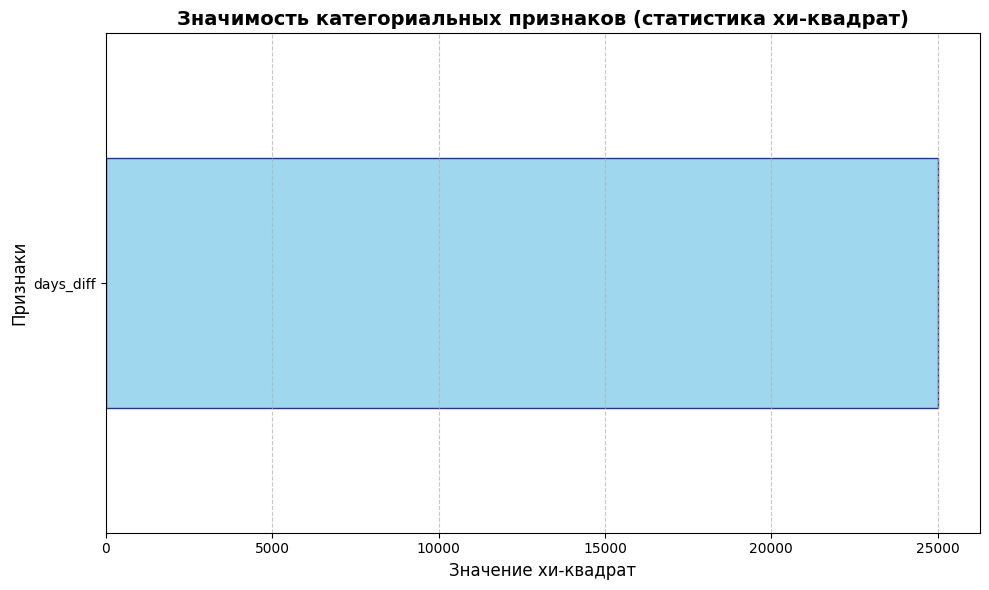


Значимость признаков:
                   Chi2  p‑value
days_diff  25024.246005      0.0


In [423]:
X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score'] 

# Убедимся, что целевая переменная имеет целочисленный тип
y = y.astype('int')

# категориальные признаки
cat_cols = ['days_diff']

# Проверка: все ли признаки в X[cat_cols] неотрицательные
# sklearn.feature_selection.chi2 требует неотрицательных значений
assert (X[cat_cols] >= 0).all().all(), \
   "Все категориальные признаки должны содержать только неотрицательные значения"


# Вычисляем статистику хи‑квадрат и p‑values
chi2_scores, p_values = chi2(X[cat_cols], y)

# Создаём Series с именами признаков и значениями хи‑квадрат
imp_cat = pd.Series(chi2_scores, index=cat_cols)

# Сортируем по возрастанию значений хи‑квадрат (для удобного отображения на графике)
imp_cat.sort_values(inplace=True)


# Визуализация
plt.figure(figsize=(10, 6))
imp_cat.plot(kind='barh', color='skyblue', edgecolor='navy', alpha=0.8)
plt.title('Значимость категориальных признаков (статистика хи‑квадрат)', fontsize=14, fontweight='bold')
plt.xlabel('Значение хи‑квадрат', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Дополнительно: выводим таблицу значимости с p‑значениями
print("\nЗначимость признаков:")
result_df = pd.DataFrame({
    'Chi2': chi2_scores,
    'p‑value': p_values
}, index=cat_cols).sort_values('Chi2')
print(result_df)

---

## Оценка значимости количественных признаков

In [424]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 26 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                386803 non-null  int64  
 1   average_score                               386803 non-null  float64
 2   review_total_negative_word_counts           386803 non-null  int64  
 3   total_number_of_reviews                     386803 non-null  int64  
 4   review_total_positive_word_counts           386803 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  386803 non-null  int64  
 6   reviewer_score                              386803 non-null  float64
 7   days_since_review                           386803 non-null  object 
 8   lat                                         386803 non-null  float64
 9   lng                                         386803 non-null  float64
 

<Axes: >

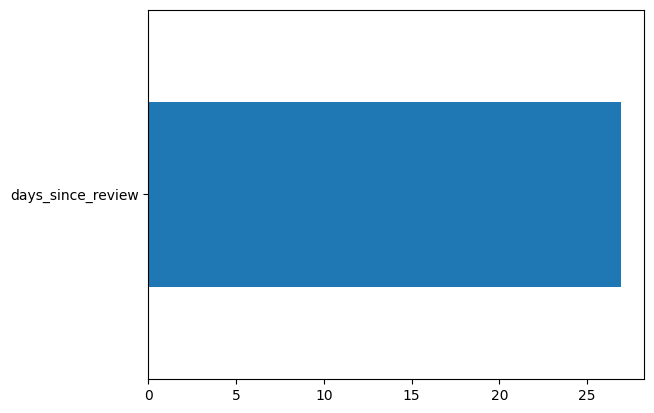

In [431]:
from sklearn.feature_selection import f_classif # anova

X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score'] 

# Убедимся, что целевая переменная имеет целочисленный тип
y = y.astype('int')

# категориальные признаки
num_cols = ['days_since_review']

imp_num = pd.Series(f_classif(X[num_cols], y)[0], index = num_cols)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')

'additional_number_of_scoring' = 210-215
'average_score' = 7500
'review_total_negative_word_counts' = 8500
'total_number_of_reviews' = 270
'review_total_positive_word_counts' = 2500
'total_number_of_reviews_reviewer_has_given' = 300
'days_since_review' = 28

In [432]:
dig_columns_to_drop = ['additional_number_of_scoring','total_number_of_reviews','total_number_of_reviews_reviewer_has_given','days_since_review']

In [433]:
hotels = hotels.drop(dig_columns_to_drop, axis = 1)

In [434]:
hotels.head()

,average_score,review_total_negative_word_counts,review_total_positive_word_counts,reviewer_score,lat,lng,days_diff,staying_in,mobile_device,negative_coefficient,...,country_Austria,country_Spain,reviewer_nationality_2,reviewer_nationality_3,reviewer_nationality_6,type_of_trip_Leisure trip,type_of_trip_Business trip,guests_Couple,guests_Solo traveler,roome_type_5
0,8.4,3,4,10.0,51.507894,-0.143671,199,2,1,3,...,0,0,0,0,0,1,0,1,0,0
1,8.3,3,2,6.3,51.521009,-0.123097,527,1,0,3,...,0,0,0,0,0,0,1,1,0,0
2,8.9,6,0,7.5,48.845377,2.325643,441,3,1,6,...,0,0,0,0,1,1,0,0,1,0
3,7.5,0,11,10.0,48.888697,2.394540,49,1,0,0,...,0,0,0,0,0,1,0,0,1,0
4,8.5,4,20,9.6,52.385601,4.847060,214,6,0,4,...,0,0,0,0,1,0,1,1,0,0


<Axes: >

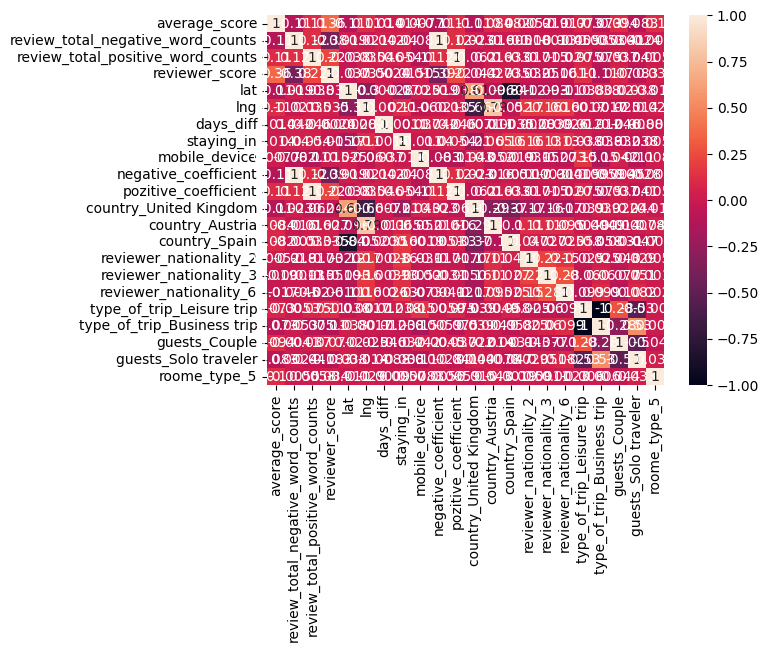

In [439]:
sns.heatmap(hotels.corr(numeric_only=True), annot=True)

In [440]:
def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    '''Получаем диагональную и нижнюю треугольную пары корреляционной матрицы'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

get_top_abs_correlations(hotels, 10) 

type_of_trip_Leisure trip          type_of_trip_Business trip    1.000000
review_total_positive_word_counts  pozitive_coefficient          0.999984
review_total_negative_word_counts  negative_coefficient          0.999795
lat                                country_Spain                 0.844057
lng                                country_Austria               0.789732
                                   country_United Kingdom        0.660440
lat                                country_United Kingdom        0.608685
type_of_trip_Business trip         guests_Solo traveler          0.528405
type_of_trip_Leisure trip          guests_Solo traveler          0.528405
guests_Couple                      guests_Solo traveler          0.502508
dtype: float64

Наблюдается мультиколлениарность. Удалим признаки 

In [441]:
hotels = hotels.drop(['type_of_trip_Leisure trip', 'review_total_positive_word_counts', 'review_total_negative_word_counts',
                      'lat', 'lng'], axis = 1)

---

In [442]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score'] 

In [443]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [444]:
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test) 

In [445]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.13573709584649324


>Действия: 13,05
* проработаны категориальные признаки, созданы новые, проведена кодировка
>Результат:
* MAPE: 0.13344303047520514
* Метрика улучшилась лишь на 0.066, результат неудовлетворительный.
>Предложения:
* возвращаемся в начало. строим матрицу корреляций.  
* проводим стат.тесты. Ищем влияние на целевую переменную. удаляем менее значимые признаки
* шкалирование числовых признаков

>Действия: 14,05
* пРоведены тесты хи квадрат для всех кат.признаков. точка отсечения - 350.
* проведения тесты с числовыми признаками. убрал всех малышей
* Удалил все столбцы соответствующие точке отсечения
* матрица корреляции показала мультиколениальность. убрал признаки из левого столбца
>Результат:
* MAPE: 0.13573709584649324
* Метрика ухудшилась
>Предложения:
* проводим шкалирование числовых признаков 
* пробуем уменьшить точку отсечения
* еще раз проверяем мультиколениальность